<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td  style="border: none!important;">
        <img width=230 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                <h1 align=center><font size=5 color="#045F5F"> <b>Alireza Karimi</b><br><br>810101492</i></font></h1>
                </td>
                <td style="border: none!important;">
        <img width=300 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>



# Q1(without RDD)
just to validate the answers

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd


file_path = '/content/drive/MyDrive/dmls/ca3/q1/videoـgameـsales.csv'

try:
    vgs = pd.read_csv(file_path)
    print('Data loaded successfully!')
    display(vgs.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully!


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [3]:
vgs.groupby("title")["total_sales"].sum().sort_values(ascending=False).head(10)

,total_sales
title,
Grand Theft Auto V,64.29
Call of Duty: Black Ops,30.99
Call of Duty: Modern Warfare 3,30.71
Call of Duty: Black Ops II,29.59
Call of Duty: Ghosts,28.80
Call of Duty: Black Ops 3,26.72
Call of Duty: Modern Warfare 2,25.02
Minecraft,24.01
Grand Theft Auto IV,22.53


In [4]:
vgs["critic_score"].unique()

array([ 9.4,  9.7,  9.6,  nan,  8.1,  8.7,  8.8,  9.8,  8.4,  8. ,  9.5,
        8.3, 10. ,  8.9,  6.9,  7.5,  9.3,  9. ,  7.9,  8.6,  8.5,  7.1,
        9.1,  9.2,  6.6,  8.2,  7.6,  5.9,  7. ,  7.8,  7.7,  6.8,  5.6,
        4.2,  7.4,  7.3,  6.7,  7.2,  6.1,  6.2,  3.5,  3. ,  3.6,  6.5,
        2.6,  6. ,  5.5,  5.8,  4.8,  5.4,  6.3,  6.4,  4.4,  3.2,  5. ,
        3.8,  5.1,  4.3,  4.5,  4.9,  5.3,  4.6,  5.7,  2.9,  4.7,  1.7,
        4.1,  4. ,  3.9,  5.2,  3.7,  2.8,  3.1,  3.3,  1.9,  2.5,  2.4,
        2. ,  2.7,  3.4,  2.3,  1.5,  1. ,  2.2,  1.4,  1.3,  9.9,  1.2,
        1.8,  2.1])

#Q1

I used [this website](https://sparkbyexamples.com/pyspark-rdd/) and [these examples](https://github.com/spark-examples/pyspark-examples) to get familiar with the RDD.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
file_path = '/content/drive/MyDrive/dmls/ca3/q1/videoـgameـsales.csv'

In [7]:
# Install PySpark
!pip install pyspark

# Imports
from pyspark.sql import SparkSession

Initialize Spark:
Create a session to get the SparkContext (sc), which is the entry point for RDDs.

In [8]:
spark = SparkSession.builder.appName("Q1").getOrCreate()
sc = spark.sparkContext

getOrCreate() – This returns a SparkSession object if already exists, and creates a new one if not exist.


In [9]:
raw_rdd = sc.textFile(file_path)
raw_rdd.first()

'img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update'

When we use parallelize(), textFile() or wholeTextFiles() methods of SparkContxt to initiate RDD, it automatically splits the data into partitions based on resource availability. When you run it on a laptop, it creates partitions as the same number of cores available on your system.

In [10]:
# Get partition count
print("Initial partition count:"+str(raw_rdd.getNumPartitions()))

Initial partition count:2


In [11]:
raw_rdd.count()

64017

In [12]:
# 3. Remove Header
header = raw_rdd.first()
data_rdd = raw_rdd.filter(lambda line: line != header)

In [13]:
header

'img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update'

In [14]:
data_rdd

PythonRDD[5] at RDD at PythonRDD.scala:56

## 1

In [15]:
import csv

def parse_line(line):
    # parts = line.split(",")
    # Using the csv module is safer than split(',') in case titles contain commas
    reader = csv.reader([line])
    parts = next(reader)
    return parts
# Define Parsing Function
def parse_line_title_total_sales(line):
    parts = parse_line(line)
    try:
        # Index 1 is Title, Index 7 is Total_Sales
        title = parts[1]
        sales = float(parts[7])
    except (IndexError, ValueError):
        return None # Handle bad lines or missing values

    return (title, sales)

I got this parse_sales function from [this chat](https://gemini.google.com/share/80b9d3df581f). I actually gave it the pdf and I asked it to help me to solve the question. I actually gave it some of the wrong codes from the Pyspark RDD website.


In [16]:
# Process Data
# map: parse lines -> filter: remove None -> reduceByKey: sum sales
top_games_rdd = (
    data_rdd
    .map(parse_line_title_total_sales)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a, b: a + b)
)

1. .map(parse_sales): Takes every raw line of text from the file and converts it into a pair: ("Game Title", Sales_Number). If the line is bad/empty, it returns None

2. .filter(lambda x: x is not None): Clean-up step. It removes any None values produced by the previous step, keeping only valid (Title, Sales) pairs

3. .reduceByKey(lambda a, b: a + b): The aggregation step. It finds all pairs with the same Game Title (the Key) and adds their Sales numbers together (a + b)

In [17]:
# Get Top 10 Results
# Sort by sales (index 1 of the tuple) in descending order
top_10 = top_games_rdd.sortBy(lambda x: x[1], ascending=False).take(10)

The Action: take(10)

What it does: It forces Spark to execute all the previous steps (map, filter, reduceByKey) and returns the top 10 results.

In [18]:
# Print Results
for game in top_10:
    print(f"Game: {game[0]} ---> Total Sales: {round(game[1],2)}")

Game: Grand Theft Auto V ---> Total Sales: 64.29
Game: Call of Duty: Black Ops ---> Total Sales: 30.99
Game: Call of Duty: Modern Warfare 3 ---> Total Sales: 30.71
Game: Call of Duty: Black Ops II ---> Total Sales: 29.59
Game: Call of Duty: Ghosts ---> Total Sales: 28.8
Game: Call of Duty: Black Ops 3 ---> Total Sales: 26.72
Game: Call of Duty: Modern Warfare 2 ---> Total Sales: 25.02
Game: Minecraft ---> Total Sales: 24.01
Game: Grand Theft Auto IV ---> Total Sales: 22.53
Game: Call of Duty: Advanced Warfare ---> Total Sales: 21.78


---

## 2

In [19]:
def parse_genre_sales(line):
  parts=parse_line(line)
  try:
    genre = parts[3]
    na_sales = float(parts[8])
    jp_sales = float(parts[9])
    pal_sales = float(parts[10])
  except:
    return None
  return (genre, (na_sales, jp_sales, pal_sales))


In [20]:
genre_sums = (data_rdd
    .map(parse_genre_sales)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a, b: (
    a[0] + b[0],  # Sum NA Sales
    a[1] + b[1],  # Sum JP Sales
    a[2] + b[2]   # Sum PAL Sales
)))

I again got some help from [this chat](https://gemini.google.com/share/3a31e1e59be0) to plot these results.

In [21]:
# results will be a list of tuples: [('Action', (100, 50, 40)), ('Sports', (120, 30, 60)), ...]
genre_sums_results = genre_sums.collect()
genre_sums_results

[('Action', (247.3500000000003, 39.46000000000002, 186.72000000000003)),
 ('Shooter', (303.3400000000006, 22.62000000000005, 211.98000000000008)),
 ('Sports', (138.57000000000005, 35.34000000000005, 170.71)),
 ('Role-Playing', (103.77999999999996, 47.69, 59.15)),
 ('Racing', (85.11999999999995, 11.789999999999978, 84.88999999999996)),
 ('Fighting', (69.81999999999998, 21.11000000000001, 38.12)),
 ('Adventure', (34.52000000000003, 9.179999999999998, 28.44000000000002)),
 ('Music', (3.2, 0.63, 1.03)),
 ('Party', (0.77, 0.66, 0.72)),
 ('Action-Adventure',
  (35.959999999999994, 4.129999999999997, 38.94999999999999)),
 ('Misc', (49.02000000000001, 9.739999999999991, 29.120000000000008)),
 ('Simulation', (33.24, 9.129999999999995, 21.63000000000001)),
 ('Platform', (54.23000000000002, 14.13999999999999, 34.47000000000003)),
 ('Puzzle', (14.659999999999998, 9.509999999999996, 5.099999999999995)),
 ('Sandbox', (0.69, 0.52, 0.56)),
 ('Strategy', (10.49, 4.81, 4.019999999999997)),
 ('MMO', (0.8

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Unpack the data
genres = [row[0] for row in genre_sums_results]
na_sales = [row[1][0] for row in genre_sums_results]
jp_sales = [row[1][1] for row in genre_sums_results]
pal_sales = [row[1][2] for row in genre_sums_results]

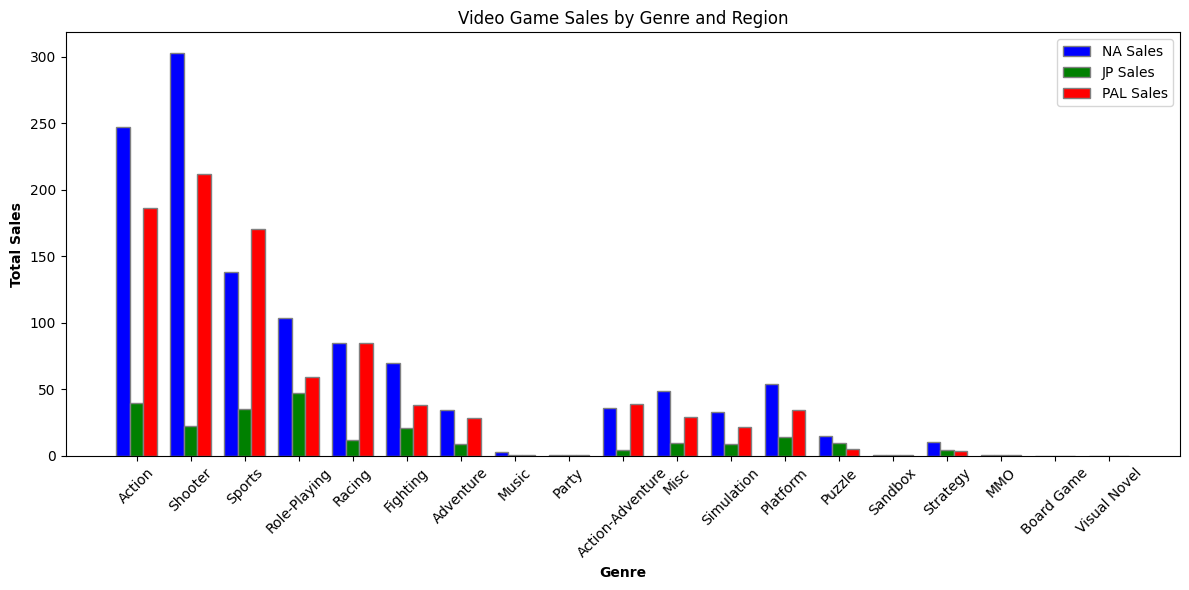

In [23]:
# Set the width of the bars
bar_width = 0.25

# Set position of bars on X axis
r1 = np.arange(len(genres))        # Position for NA Sales
r2 = [x + bar_width for x in r1]   # Position for JP Sales
r3 = [x + bar_width for x in r2]   # Position for PAL Sales

# Create the plot
plt.figure(figsize=(12, 6)) # Make it big enough to read

plt.bar(r1, na_sales, color='blue', width=bar_width, edgecolor='grey', label='NA Sales')
plt.bar(r2, jp_sales, color='green', width=bar_width, edgecolor='grey', label='JP Sales')
plt.bar(r3, pal_sales, color='red', width=bar_width, edgecolor='grey', label='PAL Sales')

# Add labels
plt.xlabel('Genre', fontweight='bold')
plt.ylabel('Total Sales', fontweight='bold')
plt.title('Video Game Sales by Genre and Region')

# Fix X-axis ticks to show Genre names
plt.xticks([r + bar_width for r in range(len(genres))], genres, rotation=45)

# Add Legend
plt.legend()

# Show the plot
plt.tight_layout() # Adjust layout to prevent clipping of labels
plt.show()

np.arange: Creates an array of numbers [0, 1, 2, ...] to serve as the base positions for the bars.

width & Offsets: We shift the JP bars by +0.25 and PAL bars by +0.50 so they sit next to the NA bars instead of on top of them.

rotation=45: Rotates the genre names so they don't overlap if you have many genres.

---

## 3

In [28]:
# Define Parsing Function
def parse_developer_critic_score(line):
    parts = parse_line(line)
    try:
        developer = parts[5]
        critic_score = float(parts[6])
        total_sales = float(parts[7])
        if critic_score in ["", "N/A", "NaN", "nan"]: # We have only "nan" in this dataset though.
          return None
    except:
        return None

    # 1 for the count
    return (developer, (critic_score, total_sales, 1))

In [29]:
developer_critic_score_rdd = (data_rdd
    .map(parse_developer_critic_score)
    .filter(lambda x: x is not None)
    # Reduce: Sum score, Sum sales, Sum count
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2]))
    # Calculate Average: score_sum / count
    # Format becomes: (Developer, Average_Score, Total_Sales)
    .map(lambda x: (x[0], x[1][0] / x[1][2], x[1][1]))
    # Filter: Keep only if Total Sales >= 10 million
    .filter(lambda x: x[2] >= 10.0))

In [32]:
# Sort by Average Score (Index 1) descending
top_developers = developer_critic_score_rdd.sortBy(lambda x: x[1], ascending=False).take(10)

I actually got help from gemini in [this chat](https://gemini.google.com/share/3e0ee18294b6) to find how to get the mean average for the critic score and how to actually do this part of Q.

In [33]:
print(f"{'Developer':<30} | {'Avg Score':<10} | {'Total Sales':<10}")
print("-" * 60)
for dev in top_developers:
    print(f"{dev[0]:<30} | {dev[1]:<10.2f} | {dev[2]:<10.2f}")

Developer                      | Avg Score  | Total Sales
------------------------------------------------------------
Rockstar Games                 | 9.80       | 13.94     
Rockstar North                 | 9.23       | 99.57     
Naughty Dog                    | 9.10       | 20.14     
Turn 10 Studios                | 9.10       | 12.12     
Rocksteady Studios             | 8.98       | 22.59     
BioWare Edmonton               | 8.97       | 14.04     
Bungie                         | 8.80       | 13.38     
Rockstar San Diego             | 8.77       | 22.27     
Harmonix Music Systems         | 8.65       | 29.33     
Dice                           | 8.63       | 17.32     


---